# Lingshu Dual Dataset Comparison

Systematic analysis of model behavior across two medical VQA datasets (SLAKE and VQA-RAD)
under different emotion/role prompt conditions, including:
- Accuracy
- Yes-bias (yes-rate)
- Inter-prompt answer similarity
- Role effect and Direct/Indirect style effect

## 1. Configuration

Set model name, data directory, dataset names to compare, and whether to use closed-ended questions only.

In [24]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Edit configuration here ───────────────────────────────
MODEL_PREFIX = "lingshu"
INPUT_DIR    = Path("/home/omar.mohamed/projects/EmoMedicalVLM/output/phase_2/Lingshu")
DATASETS     = ["SLAKE", "vqa-rad"]
ONLY_CLOSED  = True

DS_COLORS = {
    "SLAKE":   "#4C78A8",
    "vqa-rad": "#E45756",
}
# ─────────────────────────────────────────────────────────

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
print(f"Comparing datasets: {DATASETS}")
print(f"Input directory: {INPUT_DIR}")

Comparing datasets: ['SLAKE', 'vqa-rad']
Input directory: /home/omar.mohamed/projects/EmoMedicalVLM/output/phase_2/Lingshu


## 2. Helper Functions

Core utility functions used throughout the notebook:
- `parse_answer`: normalize model output text to Yes / No / Undecided
- `compute_metrics`: compute TP/FP/TN/FN and accuracy
- `parse_prefix`: parse dataset / conv_mode / emotion from filename
- `build_similarity_matrix`: compute pairwise answer agreement matrix across prompts
- `plot_similarity_heatmap`: render heatmap
- `yes_rate` / `mean_off_diagonal` / `get_metric`: misc computation helpers

In [25]:
def parse_answer(text):
    """Normalize raw model output to Yes / No / Undecided."""
    if text is None:
        return "Undecided"
    text = str(text).strip()
    text_lower = text.lower()
    if text.startswith("Yes"):  return "Yes"
    if text.startswith("No"):   return "No"
    has_yes = "yes" in text_lower
    has_no  = "no"  in text_lower
    if has_yes and has_no: return "Undecided"
    if has_yes: return "Yes"
    if has_no:  return "No"
    return "Undecided"


def compute_metrics(preds, gts):
    """Compute TP/FP/TN/FN and accuracy given prediction and ground-truth lists."""
    yes       = sum(p == "Yes"       for p in preds)
    no        = sum(p == "No"        for p in preds)
    undecided = sum(p == "Undecided" for p in preds)
    tp = sum((p == "Yes") and (g == "Yes") for p, g in zip(preds, gts))
    fp = sum((p == "Yes") and (g == "No")  for p, g in zip(preds, gts))
    tn = sum((p == "No")  and (g == "No")  for p, g in zip(preds, gts))
    fn = sum((p == "No")  and (g == "Yes") for p, g in zip(preds, gts))
    total_valid = yes + no
    acc = (tp + tn) / total_valid if total_valid else 0.0
    return dict(yes=yes, no=no, undecided=undecided,
                tp=tp, fp=fp, tn=tn, fn=fn, acc=acc, total=len(preds))


def parse_prefix(prefix, model_prefix):
    """
    Handles all three filename formats:
      lingshu_vqa-rad_single_indirect_patient_sadness_distress
      eval_lingshu_vqa-rad_single_indirect_patient_sadness_distress
      eval_0_100_lingshu_vqa-rad_multi_indirect_clinician_anger_frustration_closed
    """
    name = prefix
    # Strip _closed suffix
    if name.endswith("_closed"):
        name = name[:-len("_closed")]

    # Find model_prefix and start from there
    idx = name.find(model_prefix)
    if idx == -1:
        return {"dataset": "", "conv_mode": "", "emotion": ""}
    name = name[idx + len(model_prefix) + 1:]  # skip "lingshu_"

    # name is now: "vqa-rad_single_indirect_patient_sadness_distress"
    #           or "SLAKE_multi_direct_clinician_neutral"
    parts     = name.split("_")
    dataset   = parts[0]            # "SLAKE" or "vqa-rad"
    conv_mode = parts[1]            # "single" or "multi"
    emotion   = "_".join(parts[2:]) # "direct_clinician_neutral"

    return {"dataset": dataset, "conv_mode": conv_mode, "emotion": emotion}


# Map full emotion string to short display label
label_map = {
    "default": "default",
    "direct_clinician_neutral":             "clin_neutral_dir",
    "direct_clinician_fear_anxiety":        "clin_fear_dir",
    "direct_clinician_anger_frustration":   "clin_anger_dir",
    "direct_clinician_sadness_distress":    "clin_sad_dir",
    "direct_patient_neutral":               "pat_neutral_dir",
    "direct_patient_fear_anxiety":          "pat_fear_dir",
    "direct_patient_anger_frustration":     "pat_anger_dir",
    "direct_patient_sadness_distress":      "pat_sad_dir",
    "indirect_clinician_neutral":           "clin_neutral_Indir",
    "indirect_clinician_fear_anxiety":      "clin_fear_Indir",
    "indirect_clinician_anger_frustration": "clin_anger_Indir",
    "indirect_clinician_sadness_distress":  "clin_sad_Indir",
    "indirect_patient_neutral":             "pat_neutral_Indir",
    "indirect_patient_fear_anxiety":        "pat_fear_Indir",
    "indirect_patient_anger_frustration":   "pat_anger_Indir",
    "indirect_patient_sadness_distress":    "pat_sad_Indir",
}

emotion_short_map = {
    "neutral": "neutral", "fear_anxiety": "fear",
    "anger_frustration": "anger", "sadness_distress": "sad", "default": "default",
}

# Canonical prompt display order
row_order = [
    "default",
    "clin_neutral_dir",   "clin_fear_dir",   "clin_anger_dir",   "clin_sad_dir",
    "pat_neutral_dir",    "pat_fear_dir",    "pat_anger_dir",    "pat_sad_dir",
    "clin_neutral_Indir", "clin_fear_Indir", "clin_anger_Indir", "clin_sad_Indir",
    "pat_neutral_Indir",  "pat_fear_Indir",  "pat_anger_Indir",  "pat_sad_Indir",
]
multi_row_order = [x for x in row_order if x != "default"]


def prompt_style(emotion):
    if emotion == "default": return "default"
    return "direct" if emotion.startswith("direct_") else "indirect"

def prompt_role(emotion):
    if emotion == "default": return "default"
    return "clinician" if "clinician" in emotion else "patient"

def prompt_emotion(emotion):
    if emotion == "default": return "default"
    return emotion_short_map["_".join(emotion.split("_")[2:])]

def yes_rate(yes, no):
    """Fraction of Yes responses among valid (Yes/No) responses."""
    total = yes + no
    return yes / total if total else np.nan

def mean_off_diagonal(mat):
    """Mean of all off-diagonal entries in a square matrix."""
    vals = mat.astype(float).values
    n = vals.shape[0]
    return vals[~np.eye(n, dtype=bool)].mean()

def build_similarity_matrix(answer_df, columns):
    """Compute pairwise answer agreement rate between all prompt columns."""
    sim = pd.DataFrame(index=columns, columns=columns, dtype=float)
    for c1 in columns:
        a1 = answer_df[c1].tolist()
        for c2 in columns:
            a2 = answer_df[c2].tolist()
            m  = len(a1)
            sim.loc[c1, c2] = sum(x == y for x, y in zip(a1, a2)) / m if m else 0.0
    return sim

def plot_similarity_heatmap(mat, title, figsize=(10, 8), fontsize=8):
    """Render a similarity matrix as an annotated heatmap."""
    plt.figure(figsize=figsize)
    plt.imshow(mat.astype(float), aspect="auto")
    plt.colorbar(label="Similarity")
    plt.xticks(range(len(mat.columns)), mat.columns, rotation=90)
    plt.yticks(range(len(mat.index)),   mat.index)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            plt.text(j, i, f"{mat.iloc[i,j]:.2f}",
                     ha="center", va="center", fontsize=fontsize)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def get_metric(wide_df, prompt, column):
    return float(wide_df.loc[wide_df["prompt"] == prompt, column].iloc[0])

print("Helper functions loaded.")

Helper functions loaded.


## 3. Data Loading

Encapsulates the original single-dataset loading script into `load_dataset(dataset)`.
Called separately for each dataset, returns three core data structures:
- `wide_table`: one row per prompt, columns are metrics (acc / yes / no / undecided)
- `single_sim` / `multi_sim`: inter-prompt answer agreement matrices on non-consensus samples
- `yes_bias_table`: wide_table extended with yes_rate columns

All results stored in dict `data[dataset]`, accessible as `data["SLAKE"]` or `data["VQA-RAD"]`.

In [31]:
def load_dataset(dataset: str) -> dict:
    all_rows = []
    answer_rows = []

    for json_file in sorted(INPUT_DIR.glob("*.jsonl")):
        stem = json_file.stem

        # Use only eval closed files for this notebook
        if dataset.lower() not in stem.lower():
            continue
        if ONLY_CLOSED and "_closed" not in stem:
            continue
        if MODEL_PREFIX not in stem:
            continue
        # Keep only the binary closed eval family: eval_{MODEL_PREFIX}_..._closed
        if not stem.startswith(f"eval_{MODEL_PREFIX}_"):
            continue

        with open(json_file) as f:
            records = [json.loads(line) for line in f if line.strip()]

        parsed = parse_prefix(stem, MODEL_PREFIX)
        emotion_raw = parsed["emotion"]
        conv_mode = parsed["conv_mode"]
        short_label = label_map.get(emotion_raw, emotion_raw)

        # Closed eval files use evaluation = Yes / No
        preds = [parse_answer(r.get("evaluation")) for r in records]
        gts   = [parse_answer(r.get("answer")) for r in records]

        yes_count = sum(1 for p in preds if p == "Yes")
        no_count = sum(1 for p in preds if p == "No")
        undecided_count = sum(1 for p in preds if p not in ["Yes", "No"])

        tp = sum(1 for p, g in zip(preds, gts) if p == "Yes" and g == "Yes")
        fp = sum(1 for p, g in zip(preds, gts) if p == "Yes" and g == "No")
        tn = sum(1 for p, g in zip(preds, gts) if p == "No" and g == "No")
        fn = sum(1 for p, g in zip(preds, gts) if p == "No" and g == "Yes")

        total = len(records)
        acc = sum(1 for p, g in zip(preds, gts) if p == g) / total if total else 0.0

        metrics = {
            "yes": yes_count,
            "no": no_count,
            "undecided": undecided_count,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
            "acc": acc,
            "total": total,
        }

        all_rows.append({
            "prefix": stem,
            "conv_mode": conv_mode,
            "emotion": emotion_raw,
            "prompt": short_label,
            "style": prompt_style(emotion_raw),
            "role": prompt_role(emotion_raw),
            "emotion_short": prompt_emotion(emotion_raw),
            **{f"{conv_mode}_{k}": v for k, v in metrics.items()},
        })

        # Record per-question binary answers for agreement matrices
        for idx, (r, pred, gt) in enumerate(zip(records, preds, gts)):
            if len(answer_rows) <= idx:
                answer_rows.append({
                    "idx": idx,
                    "question": r.get("question", f"q_{idx}")
                })

            answer_rows[idx][stem] = pred
            if "gt" not in answer_rows[idx]:
                answer_rows[idx]["gt"] = gt

    if not all_rows:
        print(f"[WARNING] No files found for '{dataset}'. Check INPUT_DIR and filename format.")
        return {}

    raw_df = pd.DataFrame(all_rows)

    dup_mask = raw_df.duplicated(subset=["conv_mode", "prompt"], keep=False)
    if dup_mask.any():
        raise ValueError(
            f"Duplicate logical prompt entries found for {dataset}:\n" +
            raw_df.loc[dup_mask, ["prefix", "conv_mode", "emotion", "prompt"]]
                  .sort_values(["conv_mode", "prompt", "prefix"])
                  .to_string(index=False)
        )

    meta_cols = ["emotion", "prompt", "style", "role", "emotion_short"]

    single_metric_cols = [c for c in raw_df.columns if c.startswith("single_")]
    multi_metric_cols  = [c for c in raw_df.columns if c.startswith("multi_")]

    single_df = raw_df[raw_df["conv_mode"] == "single"][meta_cols + single_metric_cols].copy()
    multi_df  = raw_df[raw_df["conv_mode"] == "multi"][meta_cols + multi_metric_cols].copy()

    wide_table = pd.merge(single_df, multi_df, on=meta_cols, how="outer")

    present = [p for p in row_order if p in wide_table["prompt"].values]
    wide_table["prompt"] = pd.Categorical(wide_table["prompt"], categories=present, ordered=True)
    wide_table = wide_table.sort_values("prompt").reset_index(drop=True)

    yes_bias_table = wide_table.copy()
    if "single_yes" in yes_bias_table.columns and "single_no" in yes_bias_table.columns:
        yes_bias_table["single_yes_rate"] = yes_bias_table.apply(
            lambda r: yes_rate(r["single_yes"], r["single_no"]), axis=1
        )
    if "multi_yes" in yes_bias_table.columns and "multi_no" in yes_bias_table.columns:
        yes_bias_table["multi_yes_rate"] = yes_bias_table.apply(
            lambda r: yes_rate(r["multi_yes"], r["multi_no"]), axis=1
        )

    answer_df = pd.DataFrame(answer_rows)
    prompt_cols = [c for c in answer_df.columns if c not in ["idx", "question", "gt"]]
    single_cols = [c for c in prompt_cols if "_single_" in c]
    multi_cols  = [c for c in prompt_cols if "_multi_" in c]

    prefix_to_short = {
        c: label_map.get(parse_prefix(c, MODEL_PREFIX)["emotion"], c)
        for c in prompt_cols
    }

    def make_sim(cols, order):
        if not cols:
            return pd.DataFrame(), pd.DataFrame()

        sub_cols = [c for c in cols if c in answer_df.columns]
        if not sub_cols:
            return pd.DataFrame(), pd.DataFrame()

        sub_df = answer_df[["idx", "question", "gt"] + sub_cols].copy()

        non_consensus_mask = sub_df[sub_cols].nunique(axis=1) > 1
        non_consensus_sub = sub_df.loc[non_consensus_mask].copy()

        if non_consensus_sub.empty:
            return pd.DataFrame(), non_consensus_sub

        mat = build_similarity_matrix(non_consensus_sub, sub_cols)
        mat.index = [prefix_to_short.get(p, p) for p in mat.index]
        mat.columns = [prefix_to_short.get(p, p) for p in mat.columns]
        valid_order = [o for o in order if o in mat.index]
        mat = mat.loc[valid_order, valid_order]

        return mat, non_consensus_sub

    single_sim, single_non_consensus = make_sim(single_cols, row_order)
    multi_sim,  multi_non_consensus  = make_sim(multi_cols, multi_row_order)

    non_consensus_df = {
        "single": single_non_consensus,
        "multi": multi_non_consensus,
    }

    print(f"  [{dataset}] Loaded: {len(wide_table)} prompts, "
          f"single_sim={single_sim.shape}, multi_sim={multi_sim.shape}")

    return {
        "wide_table": wide_table,
        "yes_bias_table": yes_bias_table,
        "single_sim": single_sim,
        "multi_sim": multi_sim,
        "non_consensus_df": non_consensus_df,
    }


# Load all datasets
print("Loading data...")
data = {}
for ds in DATASETS:
    print(f"Loading {ds}...")
    data[ds] = load_dataset(ds)
print("\nAll datasets loaded.")

Loading data...
Loading SLAKE...
  [SLAKE] Loaded: 17 prompts, single_sim=(17, 17), multi_sim=(16, 16)
Loading vqa-rad...
  [vqa-rad] Loaded: 17 prompts, single_sim=(17, 17), multi_sim=(16, 16)

All datasets loaded.


## 4. Wide Table Preview

Display the summary metrics table for each dataset.
Each row is one prompt condition; columns are single/multi-turn accuracy, yes/no/undecided counts, etc.
Use this to quickly verify data loaded correctly.

In [32]:
for ds in DATASETS:
    if not data[ds]: continue
    print(f"\n{'='*60}")
    print(f"  {ds} Wide Table")
    print(f"{'='*60}")
    display(data[ds]["wide_table"].round(3))


  SLAKE Wide Table


,emotion,prompt,style,role,emotion_short,single_yes,single_no,single_undecided,single_tp,single_fp,single_tn,single_fn,single_acc,single_total,multi_yes,multi_no,multi_undecided,multi_tp,multi_fp,multi_tn,multi_fn,multi_acc,multi_total
0,default,default,default,default,default,172.0,183.0,0.0,169.0,3.0,177.0,6.0,0.975,355.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,direct_clinician_neutral,clin_neutral_dir,direct,clinician,neutral,173.0,182.0,0.0,169.0,4.0,176.0,6.0,0.972,355.0,174.0,181.0,0.0,169.0,5.0,175.0,6.0,0.969,355.0
2,direct_clinician_fear_anxiety,clin_fear_dir,direct,clinician,fear,176.0,179.0,0.0,171.0,5.0,175.0,4.0,0.975,355.0,175.0,180.0,0.0,170.0,5.0,175.0,5.0,0.972,355.0
3,direct_clinician_anger_frustration,clin_anger_dir,direct,clinician,anger,172.0,183.0,0.0,169.0,3.0,177.0,6.0,0.975,355.0,173.0,182.0,0.0,169.0,4.0,176.0,6.0,0.972,355.0
4,direct_clinician_sadness_distress,clin_sad_dir,direct,clinician,sad,172.0,183.0,0.0,169.0,3.0,177.0,6.0,0.975,355.0,172.0,183.0,0.0,168.0,4.0,176.0,7.0,0.969,355.0
5,direct_patient_neutral,pat_neutral_dir,direct,patient,neutral,173.0,182.0,0.0,169.0,4.0,176.0,6.0,0.972,355.0,174.0,181.0,0.0,169.0,5.0,175.0,6.0,0.969,355.0
6,direct_patient_fear_anxiety,pat_fear_dir,direct,patient,fear,175.0,180.0,0.0,169.0,6.0,174.0,6.0,0.966,355.0,173.0,182.0,0.0,169.0,4.0,176.0,6.0,0.972,355.0
7,direct_patient_anger_frustration,pat_anger_dir,direct,patient,anger,173.0,182.0,0.0,169.0,4.0,176.0,6.0,0.972,355.0,173.0,182.0,0.0,169.0,4.0,176.0,6.0,0.972,355.0
8,direct_patient_sadness_distress,pat_sad_dir,direct,patient,sad,172.0,183.0,0.0,169.0,3.0,177.0,6.0,0.975,355.0,173.0,182.0,0.0,169.0,4.0,176.0,6.0,0.972,355.0
9,indirect_clinician_neutral,clin_neutral_Indir,indirect,clinician,neutral,172.0,183.0,0.0,166.0,6.0,174.0,9.0,0.958,355.0,174.0,181.0,0.0,168.0,6.0,174.0,7.0,0.963,355.0



  vqa-rad Wide Table


,emotion,prompt,style,role,emotion_short,single_yes,single_no,single_undecided,single_tp,single_fp,single_tn,single_fn,single_acc,single_total,multi_yes,multi_no,multi_undecided,multi_tp,multi_fp,multi_tn,multi_fn,multi_acc,multi_total
0,default,default,default,default,default,110.0,141.0,0.0,88.0,22.0,111.0,30.0,0.793,251.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,direct_clinician_neutral,clin_neutral_dir,direct,clinician,neutral,110.0,141.0,0.0,89.0,21.0,112.0,29.0,0.801,251.0,109.0,142.0,0.0,87.0,22.0,111.0,31.0,0.789,251.0
2,direct_clinician_fear_anxiety,clin_fear_dir,direct,clinician,fear,103.0,148.0,0.0,82.0,21.0,112.0,36.0,0.773,251.0,109.0,142.0,0.0,87.0,22.0,111.0,31.0,0.789,251.0
3,direct_clinician_anger_frustration,clin_anger_dir,direct,clinician,anger,100.0,151.0,0.0,82.0,18.0,115.0,36.0,0.785,251.0,107.0,144.0,0.0,87.0,20.0,113.0,31.0,0.797,251.0
4,direct_clinician_sadness_distress,clin_sad_dir,direct,clinician,sad,101.0,150.0,0.0,82.0,19.0,114.0,36.0,0.781,251.0,110.0,141.0,0.0,89.0,21.0,112.0,29.0,0.801,251.0
5,direct_patient_neutral,pat_neutral_dir,direct,patient,neutral,108.0,143.0,0.0,86.0,22.0,111.0,32.0,0.785,251.0,109.0,142.0,0.0,87.0,22.0,111.0,31.0,0.789,251.0
6,direct_patient_fear_anxiety,pat_fear_dir,direct,patient,fear,104.0,147.0,0.0,84.0,20.0,113.0,34.0,0.785,251.0,108.0,143.0,0.0,87.0,21.0,112.0,31.0,0.793,251.0
7,direct_patient_anger_frustration,pat_anger_dir,direct,patient,anger,97.0,154.0,0.0,80.0,17.0,116.0,38.0,0.781,251.0,103.0,148.0,0.0,84.0,19.0,114.0,34.0,0.789,251.0
8,direct_patient_sadness_distress,pat_sad_dir,direct,patient,sad,100.0,151.0,0.0,82.0,18.0,115.0,36.0,0.785,251.0,109.0,142.0,0.0,88.0,21.0,112.0,30.0,0.797,251.0
9,indirect_clinician_neutral,clin_neutral_Indir,indirect,clinician,neutral,96.0,155.0,0.0,76.0,20.0,113.0,42.0,0.753,251.0,102.0,149.0,0.0,83.0,19.0,114.0,35.0,0.785,251.0


In [33]:
for ds in DATASETS:
    print(f"\n=== {ds} ===")
    if not data[ds]:
        print("  EMPTY")
        continue
    wt = data[ds]["wide_table"]
    print(f"  shape: {wt.shape}")
    print(f"  columns: {list(wt.columns)}")
    print(f"  prompt values: {wt['prompt'].tolist()}")
    print(wt.head(3).to_string())


=== SLAKE ===
  shape: (17, 23)
  columns: ['emotion', 'prompt', 'style', 'role', 'emotion_short', 'single_yes', 'single_no', 'single_undecided', 'single_tp', 'single_fp', 'single_tn', 'single_fn', 'single_acc', 'single_total', 'multi_yes', 'multi_no', 'multi_undecided', 'multi_tp', 'multi_fp', 'multi_tn', 'multi_fn', 'multi_acc', 'multi_total']
  prompt values: ['default', 'clin_neutral_dir', 'clin_fear_dir', 'clin_anger_dir', 'clin_sad_dir', 'pat_neutral_dir', 'pat_fear_dir', 'pat_anger_dir', 'pat_sad_dir', 'clin_neutral_Indir', 'clin_fear_Indir', 'clin_anger_Indir', 'clin_sad_Indir', 'pat_neutral_Indir', 'pat_fear_Indir', 'pat_anger_Indir', 'pat_sad_Indir']
                         emotion            prompt    style       role emotion_short  single_yes  single_no  single_undecided  single_tp  single_fp  single_tn  single_fn  single_acc  single_total  multi_yes  multi_no  multi_undecided  multi_tp  multi_fp  multi_tn  multi_fn  multi_acc  multi_total
0                        default

## 5. Accuracy Comparison: Side-by-Side Bar Charts

Side-by-side bar charts showing single/multi-turn accuracy across all prompt conditions
for both datasets. Useful for comparing how sensitive the model is to emotion prompts
on different datasets.

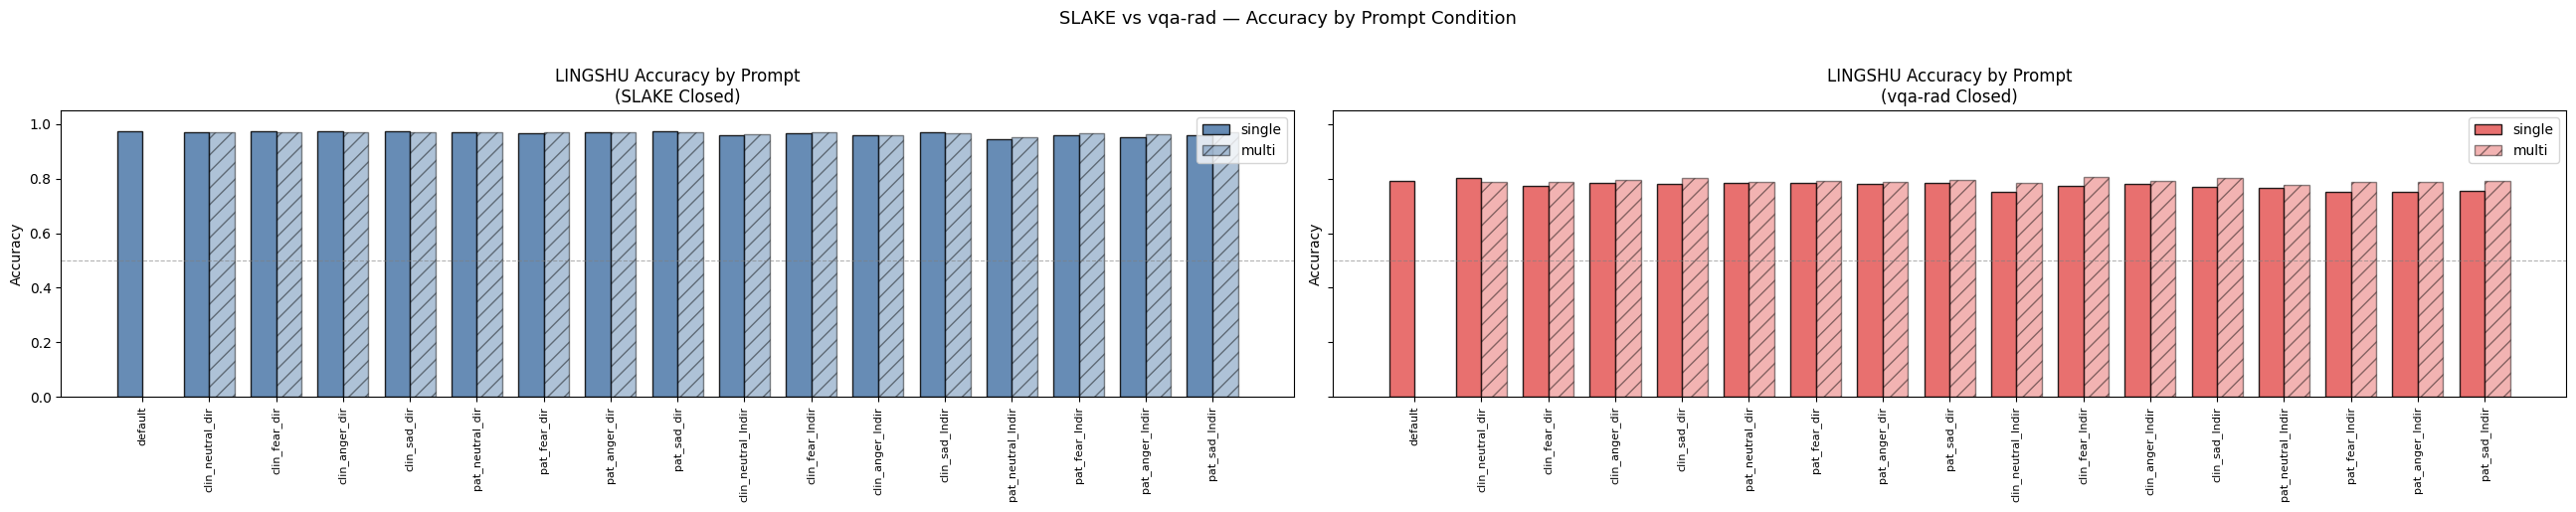

In [34]:
n_ds = len(DATASETS)
fig, axes = plt.subplots(1, n_ds, figsize=(13 * n_ds, 5), sharey=True)
if n_ds == 1:
    axes = [axes]

for ax, ds in zip(axes, DATASETS):
    if not data[ds]: continue
    df    = data[ds]["wide_table"]
    color = DS_COLORS.get(ds, "#888")
    x     = np.arange(len(df))
    w     = 0.38

    single_acc = df.get("single_acc", pd.Series([np.nan]*len(df)))
    multi_acc  = df.get("multi_acc",  pd.Series([np.nan]*len(df)))

    ax.bar(x - w/2, single_acc, width=w, label="single",
           color=color, alpha=0.85, edgecolor="black")
    ax.bar(x + w/2, multi_acc.fillna(np.nan), width=w, label="multi",
           color=color, alpha=0.45, edgecolor="black", hatch="//")

    ax.set_xticks(x)
    ax.set_xticklabels(df["prompt"], rotation=90, fontsize=8)
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{MODEL_PREFIX.upper()} Accuracy by Prompt\n({ds} Closed)")
    ax.legend()
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

plt.suptitle(f"{' vs '.join(DATASETS)} — Accuracy by Prompt Condition",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Summary Statistics Table

Compute and display summary metrics for both datasets side by side:
- **mean_single_acc / mean_multi_acc**: mean accuracy
- **mean_single_yes_rate / mean_multi_yes_rate**: mean yes-bias rate
- **off_diagonal_similarity**: cross-prompt agreement on non-consensus samples

Also shows the difference row (Dataset2 − Dataset1) when exactly two datasets are loaded.

In [35]:
summary_rows = []
for ds in DATASETS:
    if not data[ds]: continue
    wt  = data[ds]["wide_table"]
    ybt = data[ds]["yes_bias_table"]
    ssm = data[ds]["single_sim"]
    msm = data[ds]["multi_sim"]

    row = {"dataset": ds}
    for col in ("single_acc", "multi_acc"):
        if col in wt.columns:
            row[f"mean_{col}"] = round(wt[col].mean(), 3)
    for col in ("single_yes_rate", "multi_yes_rate"):
        if col in ybt.columns:
            row[f"mean_{col}"] = round(ybt[col].dropna().mean(), 3)
    if not ssm.empty:
        row["single_off_diag_sim"] = round(mean_off_diagonal(ssm), 3)
    if not msm.empty:
        row["multi_off_diag_sim"]  = round(mean_off_diagonal(msm), 3)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("dataset")
print("=== Cross-Dataset Summary ===")
display(summary_df)

# Show difference row if exactly two datasets
if len(DATASETS) == 2 and all(ds in summary_df.index for ds in DATASETS):
    diff    = summary_df.loc[DATASETS[1]] - summary_df.loc[DATASETS[0]]
    diff_df = diff.to_frame(name=f"{DATASETS[1]} − {DATASETS[0]}").T
    print(f"\n=== Difference ({DATASETS[1]} − {DATASETS[0]}) ===")
    display(diff_df.round(3))

=== Cross-Dataset Summary ===


,mean_single_acc,mean_multi_acc,mean_single_yes_rate,mean_multi_yes_rate,single_off_diag_sim,multi_off_diag_sim
dataset,,,,,,
SLAKE,0.966,0.967,0.488,0.489,0.709,0.693
vqa-rad,0.775,0.792,0.401,0.419,0.674,0.712



=== Difference (vqa-rad − SLAKE) ===


,mean_single_acc,mean_multi_acc,mean_single_yes_rate,mean_multi_yes_rate,single_off_diag_sim,multi_off_diag_sim
vqa-rad − SLAKE,-0.191,-0.175,-0.087,-0.07,-0.035,0.019


## 7. Accuracy Overlay Line Plot

Plot single/multi-turn accuracy for both datasets on the same axes.
Makes it easy to spot which prompt conditions show consistent vs. divergent behavior
across datasets.

/tmp/ipykernel_3119855/2284466382.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)


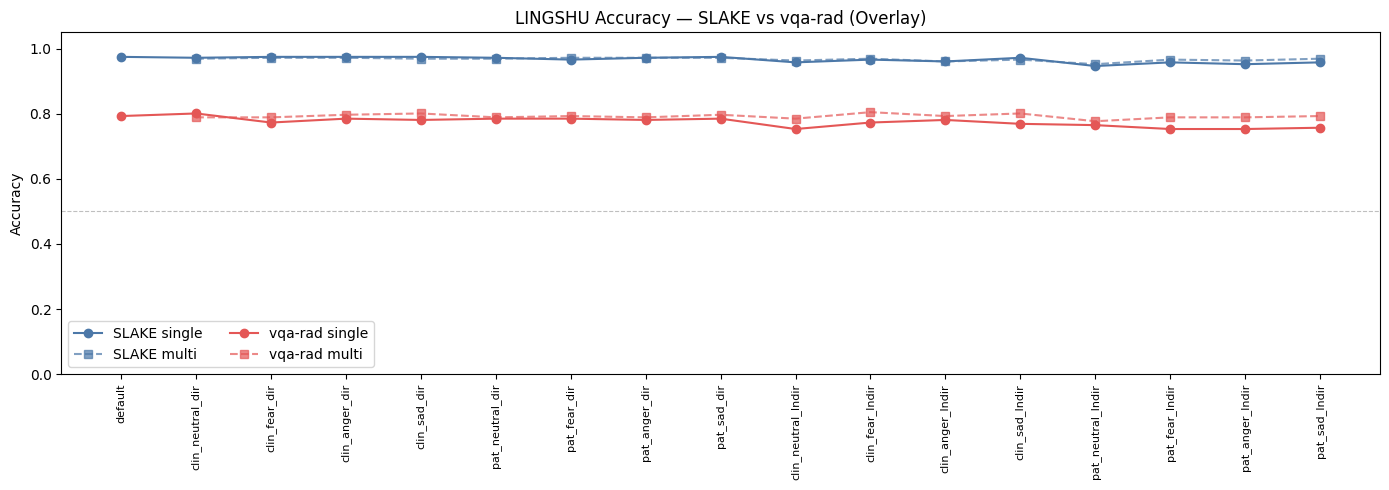

In [36]:
fig, ax = plt.subplots(figsize=(14, 5))

for ds in DATASETS:
    if not data[ds]: continue
    df    = data[ds]["wide_table"]
    color = DS_COLORS.get(ds, "#888")
    if "single_acc" in df.columns:
        ax.plot(df["prompt"], df["single_acc"],
                label=f"{ds} single", color=color,
                marker="o", linewidth=1.5)
    if "multi_acc" in df.columns:
        ax.plot(df["prompt"], df["multi_acc"],
                label=f"{ds} multi", color=color,
                marker="s", linestyle="--", linewidth=1.5, alpha=0.7)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.set_title(f"{MODEL_PREFIX.upper()} Accuracy — {' vs '.join(DATASETS)} (Overlay)")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

## 8. Inter-Prompt Similarity Heatmaps

Compute pairwise answer agreement rate across prompts on non-consensus samples
(questions where at least one prompt gives a different answer).

High similarity = two prompts produce nearly identical outputs.
Low similarity = the prompt meaningfully shifts model behavior.

Plotted separately for each dataset.

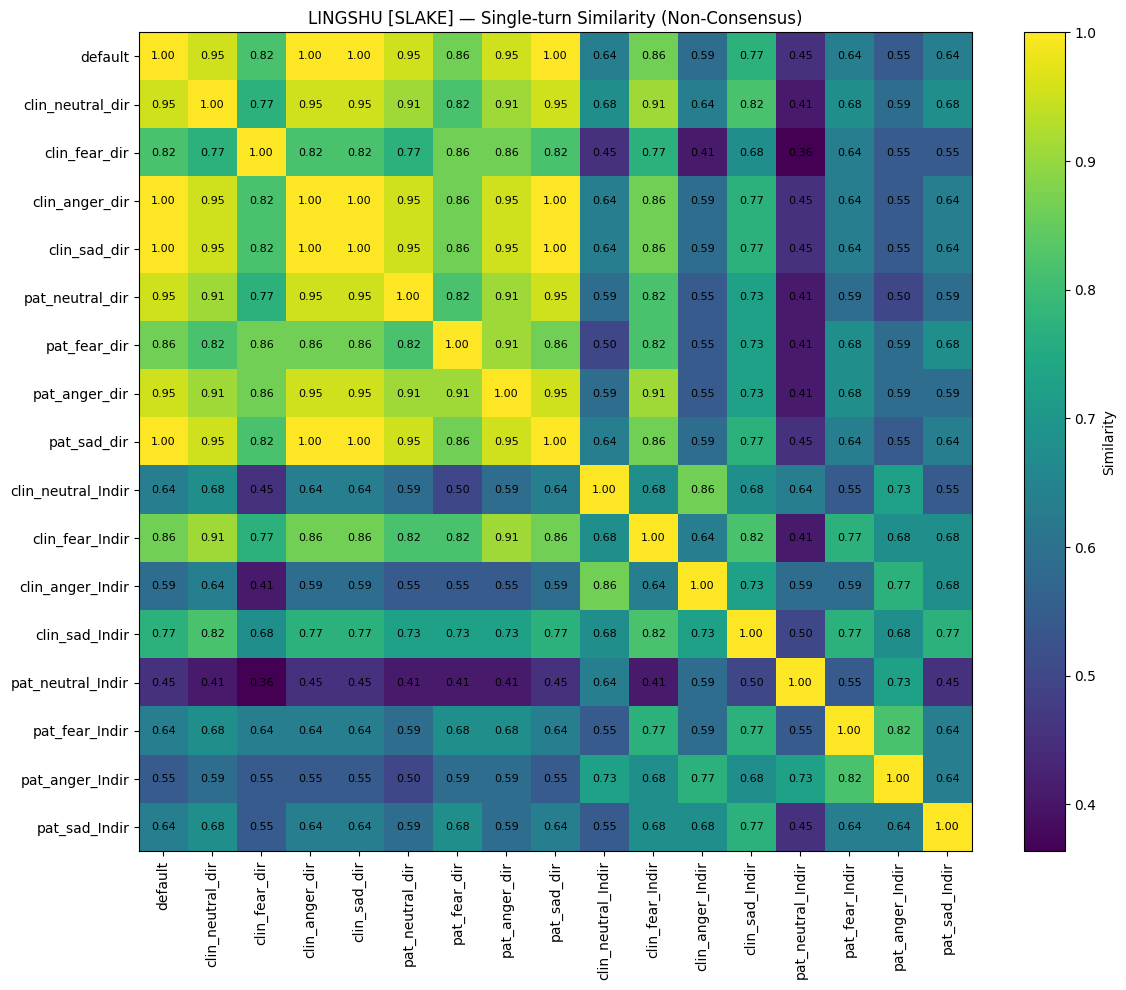

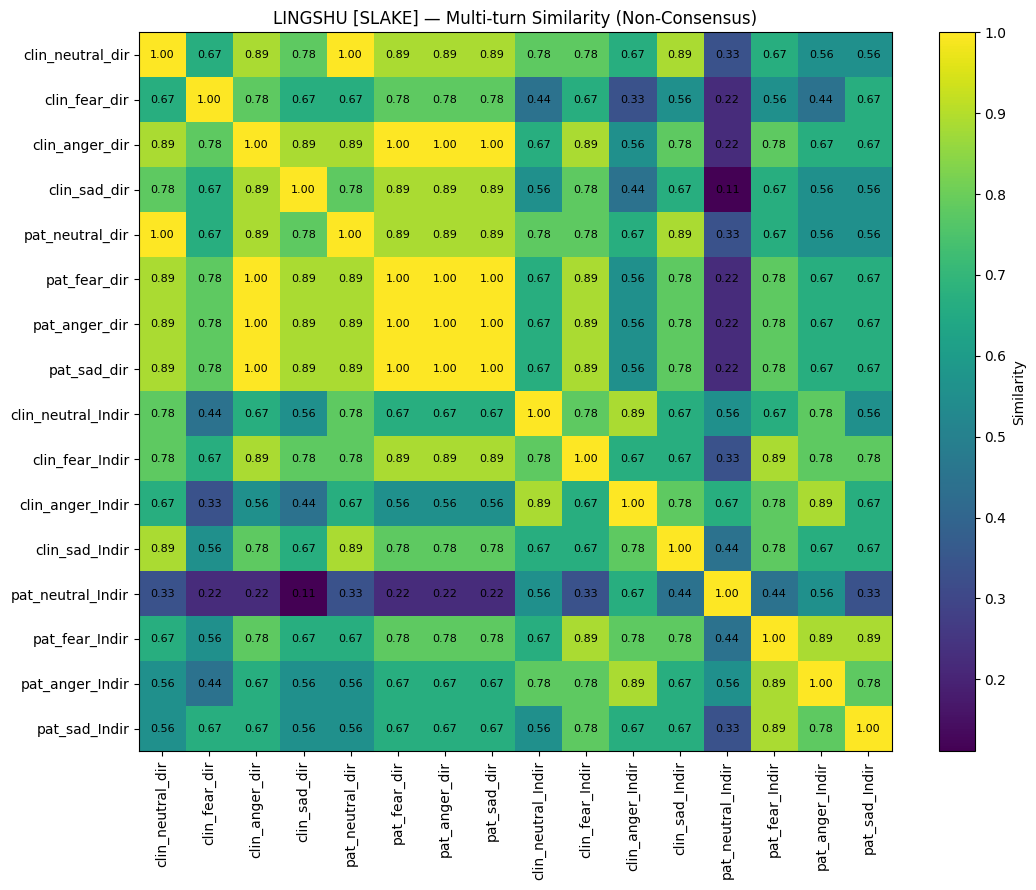

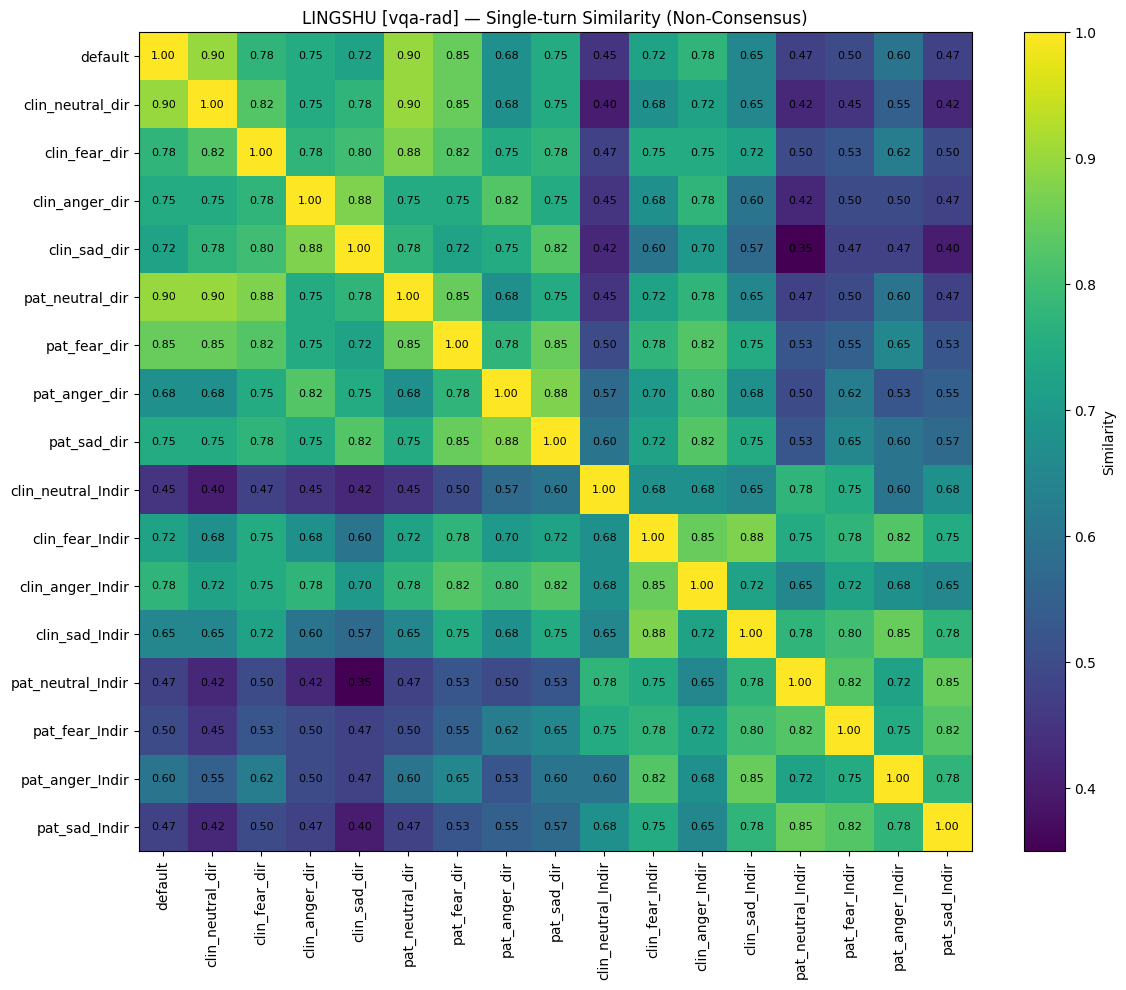

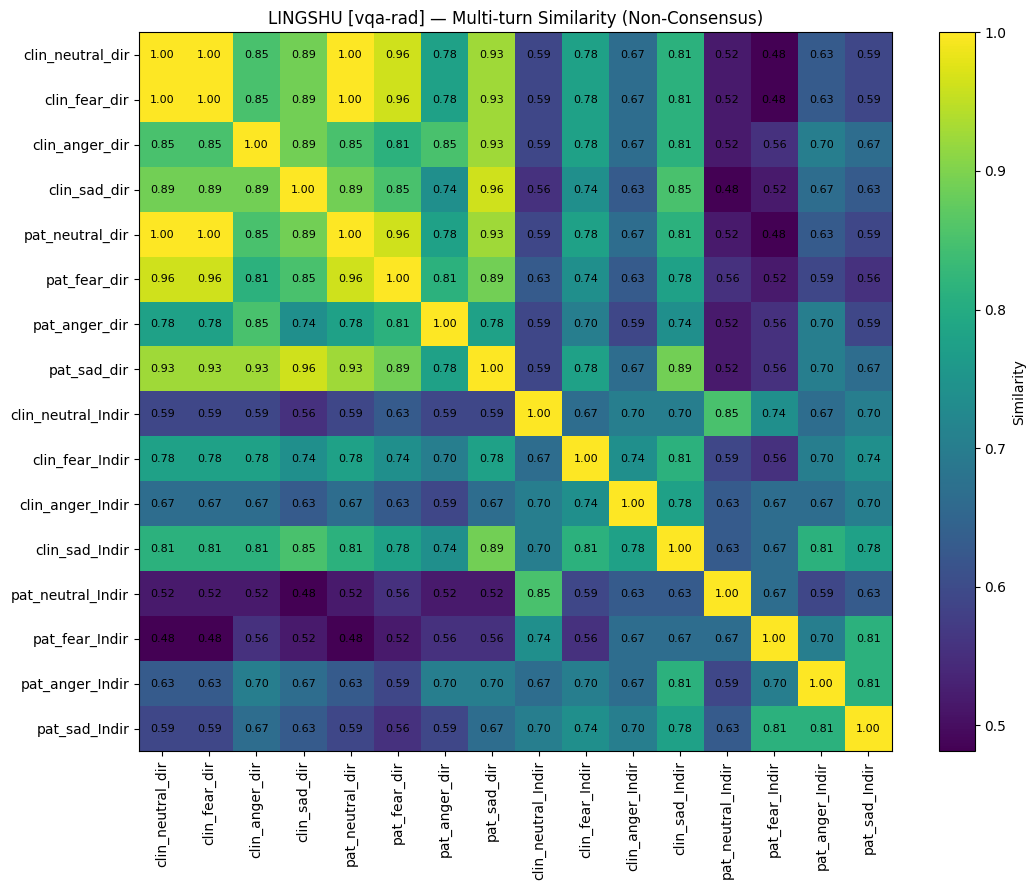

In [37]:
for ds in DATASETS:
    if not data[ds]: continue
    ssm = data[ds]["single_sim"]
    msm = data[ds]["multi_sim"]

    if not ssm.empty:
        plot_similarity_heatmap(
            ssm,
            title=f"{MODEL_PREFIX.upper()} [{ds}] — Single-turn Similarity (Non-Consensus)",
            figsize=(12, 10), fontsize=8,
        )
    if not msm.empty:
        plot_similarity_heatmap(
            msm,
            title=f"{MODEL_PREFIX.upper()} [{ds}] — Multi-turn Similarity (Non-Consensus)",
            figsize=(11, 9), fontsize=8,
        )

## 9. Role Effect: Clinician vs. Patient

For each emotion, compute the absolute gap between clinician and patient prompts
in terms of yes-rate and accuracy.

A larger gap indicates the model is more sensitive to the questioner's role.
Both datasets displayed side by side to check whether the role effect is consistent.

In [38]:
emotions = ["neutral", "fear", "anger", "sad"]
role_effect_tables = {}

for ds in DATASETS:
    if not data[ds]: continue
    wt  = data[ds]["wide_table"]
    ybt = data[ds]["yes_bias_table"]

    def _yr(prompt, mode):
        col  = f"{mode}_yes_rate"
        if col not in ybt.columns: return np.nan
        rows = ybt.loc[ybt["prompt"] == prompt, col]
        return rows.iloc[0] if len(rows) else np.nan

    def _acc(prompt, mode):
        col  = f"{mode}_acc"
        if col not in wt.columns: return np.nan
        rows = wt.loc[wt["prompt"] == prompt, col]
        return rows.iloc[0] if len(rows) else np.nan

    rows = []
    for emo in emotions:
        d_clin = f"clin_{emo}_dir";   d_pat = f"pat_{emo}_dir"
        i_clin = f"clin_{emo}_Indir"; i_pat = f"pat_{emo}_Indir"
        rows.append({
            "emotion":                 emo,
            "single_direct_yes_gap":   abs(_yr(d_clin,  "single") - _yr(d_pat,  "single")),
            "single_indirect_yes_gap": abs(_yr(i_clin,  "single") - _yr(i_pat,  "single")),
            "multi_direct_yes_gap":    abs(_yr(d_clin,  "multi")  - _yr(d_pat,  "multi")),
            "multi_indirect_yes_gap":  abs(_yr(i_clin,  "multi")  - _yr(i_pat,  "multi")),
            "single_direct_acc_gap":   abs(_acc(d_clin, "single") - _acc(d_pat, "single")),
            "single_indirect_acc_gap": abs(_acc(i_clin, "single") - _acc(i_pat, "single")),
            "multi_direct_acc_gap":    abs(_acc(d_clin, "multi")  - _acc(d_pat, "multi")),
            "multi_indirect_acc_gap":  abs(_acc(i_clin, "multi")  - _acc(i_pat, "multi")),
        })

    role_effect_tables[ds] = pd.DataFrame(rows).round(3)

for ds in DATASETS:
    if ds not in role_effect_tables: continue
    print(f"\n=== {ds} Role Effect (|Clinician − Patient|) ===")
    display(role_effect_tables[ds])


=== SLAKE Role Effect (|Clinician − Patient|) ===


,emotion,single_direct_yes_gap,single_indirect_yes_gap,multi_direct_yes_gap,multi_indirect_yes_gap,single_direct_acc_gap,single_indirect_acc_gap,multi_direct_acc_gap,multi_indirect_acc_gap
0,neutral,0.000,0.000,0.000,0.000,0.000,0.011,0.000,0.011
1,fear,0.003,0.014,0.006,0.003,0.008,0.008,0.000,0.003
2,anger,0.003,0.008,0.000,0.003,0.003,0.008,0.000,0.003
3,sad,0.000,0.003,0.003,0.003,0.000,0.014,0.003,0.003



=== vqa-rad Role Effect (|Clinician − Patient|) ===


,emotion,single_direct_yes_gap,single_indirect_yes_gap,multi_direct_yes_gap,multi_indirect_yes_gap,single_direct_acc_gap,single_indirect_acc_gap,multi_direct_acc_gap,multi_indirect_acc_gap
0,neutral,0.008,0.004,0.000,0.000,0.016,0.012,0.000,0.008
1,fear,0.004,0.028,0.004,0.024,0.012,0.020,0.004,0.016
2,anger,0.012,0.004,0.016,0.012,0.004,0.028,0.008,0.004
3,sad,0.004,0.012,0.004,0.024,0.004,0.012,0.004,0.008


### 9.1 Role Effect Visualization: Yes-rate Gap

Bar charts of clinician–patient yes-rate gap per emotion and prompt type,
plotted separately for each dataset.

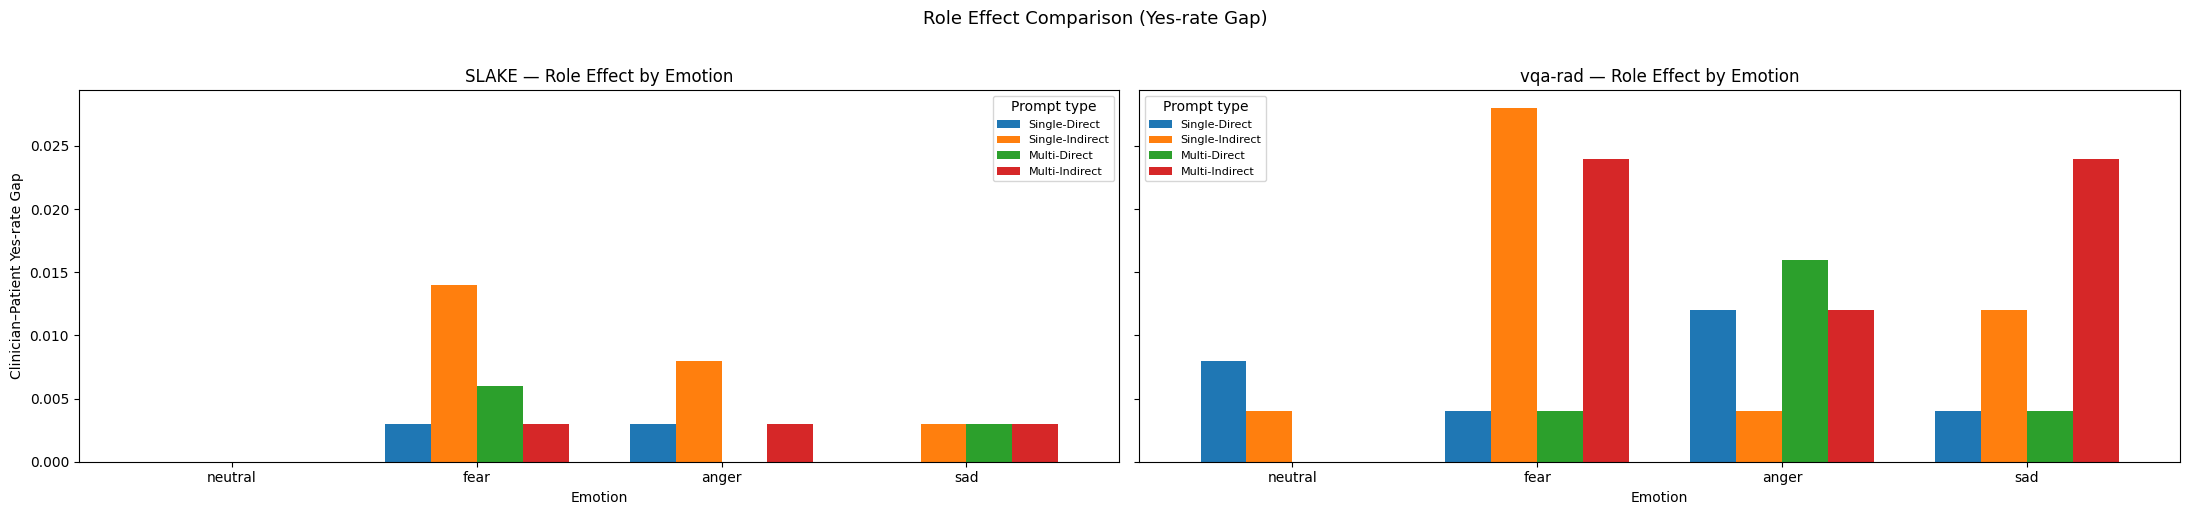

In [39]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(11 * len(DATASETS), 5), sharey=True)
if len(DATASETS) == 1:
    axes = [axes]

gap_cols   = ["single_direct_yes_gap", "single_indirect_yes_gap",
              "multi_direct_yes_gap",  "multi_indirect_yes_gap"]
col_rename = {
    "single_direct_yes_gap":   "Single-Direct",
    "single_indirect_yes_gap": "Single-Indirect",
    "multi_direct_yes_gap":    "Multi-Direct",
    "multi_indirect_yes_gap":  "Multi-Indirect",
}

for ax, ds in zip(axes, DATASETS):
    if ds not in role_effect_tables: continue
    df_plot = (
        role_effect_tables[ds]
        .set_index("emotion")[[c for c in gap_cols if c in role_effect_tables[ds].columns]]
        .rename(columns=col_rename)
    )
    df_plot.plot(kind="bar", ax=ax, width=0.75)
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Clinician–Patient Yes-rate Gap")
    ax.set_title(f"{ds} — Role Effect by Emotion")
    ax.set_xticklabels(df_plot.index, rotation=0)
    ax.legend(title="Prompt type", fontsize=8)

plt.suptitle("Role Effect Comparison (Yes-rate Gap)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Single-turn Accuracy: Role × Emotion × Style

Grouped bar charts showing accuracy across the four combinations of
role (clinician/patient) × style (direct/indirect) for each emotion.
Both datasets side by side to check cross-dataset consistency of role and style effects.

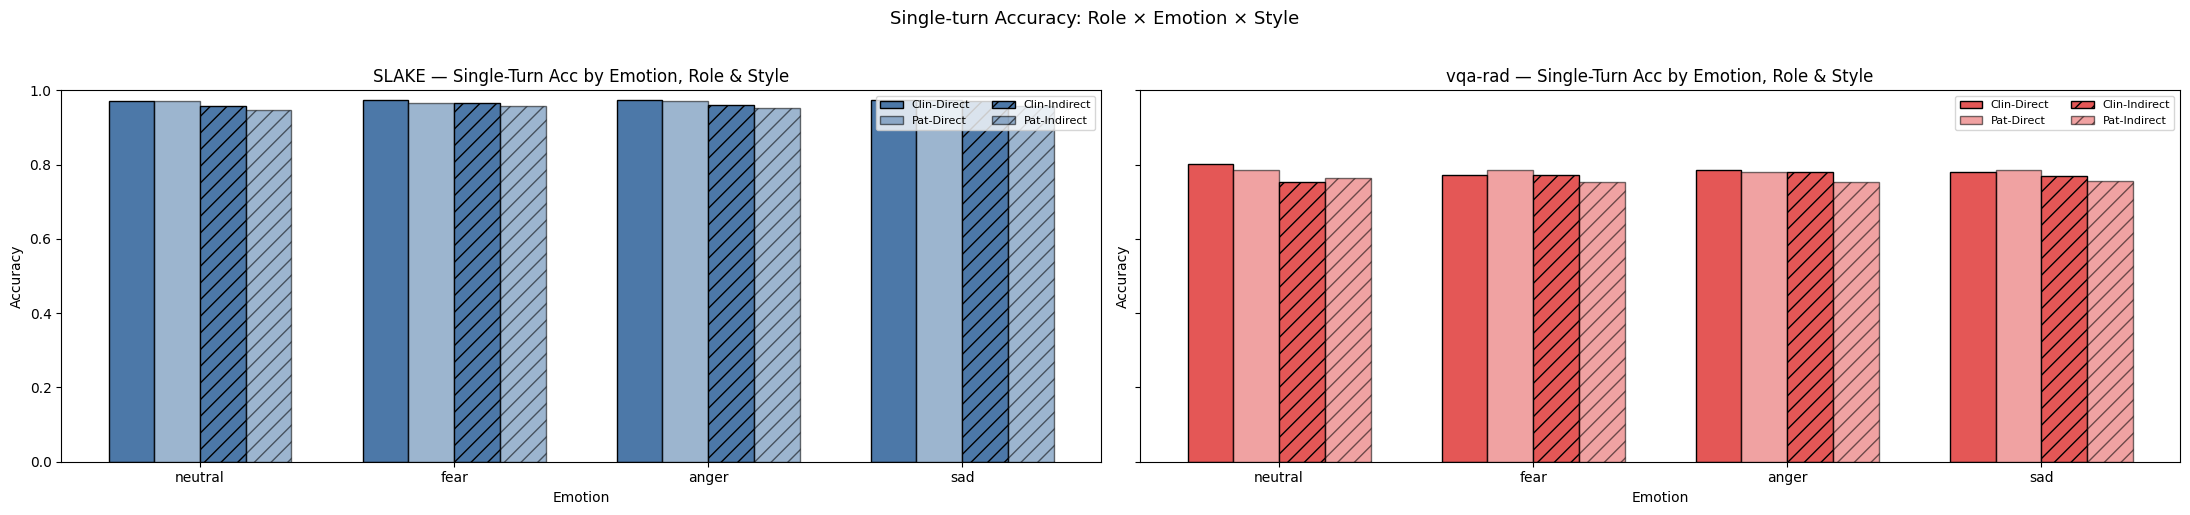

In [40]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(11 * len(DATASETS), 5), sharey=True)
if len(DATASETS) == 1:
    axes = [axes]

for ax, ds in zip(axes, DATASETS):
    if not data[ds]: continue
    wt = data[ds]["wide_table"]
    if "single_acc" not in wt.columns: continue

    plot_rows = []
    for emo in emotions:
        row = {"emotion": emo}
        for key in ("clin_direct", "pat_direct", "clin_indirect", "pat_indirect"):
            role, style = key.split("_")
            suffix = "dir" if style == "direct" else "Indir"
            prompt = f"{role}_{emo}_{suffix}"
            rows   = wt.loc[wt["prompt"] == prompt, "single_acc"]
            row[key] = rows.iloc[0] if len(rows) else np.nan
        plot_rows.append(row)

    df_role = pd.DataFrame(plot_rows).set_index("emotion")
    x       = np.arange(len(df_role))
    w       = 0.18
    color   = DS_COLORS.get(ds, "#4C78A8")

    ax.bar(x - 1.5*w, df_role["clin_direct"],   width=w, label="Clin-Direct",
           color=color, edgecolor="black")
    ax.bar(x - 0.5*w, df_role["pat_direct"],    width=w, label="Pat-Direct",
           color=color, alpha=0.55, edgecolor="black")
    ax.bar(x + 0.5*w, df_role["clin_indirect"], width=w, label="Clin-Indirect",
           color=color, edgecolor="black", hatch="//")
    ax.bar(x + 1.5*w, df_role["pat_indirect"],  width=w, label="Pat-Indirect",
           color=color, alpha=0.55, edgecolor="black", hatch="//")

    ax.set_xticks(x)
    ax.set_xticklabels(df_role.index, rotation=0)
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{ds} — Single-Turn Acc by Emotion, Role & Style")
    ax.legend(ncol=2, fontsize=8)

plt.suptitle("Single-turn Accuracy: Role × Emotion × Style", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11. Direct vs. Indirect Style Effect

For each (role, emotion) combination, compute:
- Answer agreement between direct and indirect prompts (similarity)
- Accuracy change (indirect − direct)
- Yes-rate change

Determines whether prompt framing style (explicit statement vs. implied context)
meaningfully shifts model outputs.

In [41]:
di_tables = {}

for ds in DATASETS:
    if not data[ds]: continue
    wt  = data[ds]["wide_table"]
    ybt = data[ds]["yes_bias_table"]
    ssm = data[ds]["single_sim"]
    msm = data[ds]["multi_sim"]

    def _safe_sim(mat, r, c):
        try:   return float(mat.loc[r, c])
        except: return np.nan

    def _acc(prompt, mode):
        col  = f"{mode}_acc"
        if col not in wt.columns: return np.nan
        rows = wt.loc[wt["prompt"] == prompt, col]
        return rows.iloc[0] if len(rows) else np.nan

    def _yr2(prompt, mode):
        col  = f"{mode}_yes_rate"
        if col not in ybt.columns: return np.nan
        rows = ybt.loc[ybt["prompt"] == prompt, col]
        return rows.iloc[0] if len(rows) else np.nan

    rows = []
    for role_prefix in ["clin", "pat"]:
        for emo in emotions:
            dp = f"{role_prefix}_{emo}_dir"
            ip = f"{role_prefix}_{emo}_Indir"
            rows.append({
                "condition":           f"{role_prefix}_{emo}",
                "single_similarity":   _safe_sim(ssm, dp, ip),
                "multi_similarity":    _safe_sim(msm, dp, ip),
                "single_acc_direct":   _acc(dp, "single"),
                "single_acc_indirect": _acc(ip, "single"),
                "single_acc_change":   _acc(ip, "single") - _acc(dp, "single"),
                "multi_acc_direct":    _acc(dp, "multi"),
                "multi_acc_indirect":  _acc(ip, "multi"),
                "multi_acc_change":    _acc(ip, "multi") - _acc(dp, "multi"),
                "single_yr_direct":    _yr2(dp, "single"),
                "single_yr_indirect":  _yr2(ip, "single"),
                "multi_yr_direct":     _yr2(dp, "multi"),
                "multi_yr_indirect":   _yr2(ip, "multi"),
            })

    di_tables[ds] = pd.DataFrame(rows)
    print(f"\n=== {ds} Direct vs. Indirect ===")
    display(di_tables[ds].round(3))


=== SLAKE Direct vs. Indirect ===


,condition,single_similarity,multi_similarity,single_acc_direct,single_acc_indirect,single_acc_change,multi_acc_direct,multi_acc_indirect,multi_acc_change,single_yr_direct,single_yr_indirect,multi_yr_direct,multi_yr_indirect
0,clin_neutral,0.682,0.778,0.972,0.958,-0.014,0.969,0.963,-0.006,0.487,0.485,0.490,0.490
1,clin_fear,0.773,0.667,0.975,0.966,-0.008,0.972,0.969,-0.003,0.496,0.487,0.493,0.485
2,clin_anger,0.591,0.556,0.975,0.961,-0.014,0.972,0.961,-0.011,0.485,0.487,0.487,0.493
3,clin_sad,0.773,0.667,0.975,0.972,-0.003,0.969,0.966,-0.003,0.485,0.487,0.485,0.493
4,pat_neutral,0.409,0.333,0.972,0.946,-0.025,0.969,0.952,-0.017,0.487,0.485,0.490,0.490
5,pat_fear,0.682,0.778,0.966,0.958,-0.008,0.972,0.966,-0.006,0.493,0.501,0.487,0.487
6,pat_anger,0.591,0.667,0.972,0.952,-0.020,0.972,0.963,-0.008,0.487,0.496,0.487,0.490
7,pat_sad,0.636,0.667,0.975,0.958,-0.017,0.972,0.969,-0.003,0.485,0.485,0.487,0.490



=== vqa-rad Direct vs. Indirect ===


,condition,single_similarity,multi_similarity,single_acc_direct,single_acc_indirect,single_acc_change,multi_acc_direct,multi_acc_indirect,multi_acc_change,single_yr_direct,single_yr_indirect,multi_yr_direct,multi_yr_indirect
0,clin_neutral,0.400,0.593,0.801,0.753,-0.048,0.789,0.785,-0.004,0.438,0.382,0.434,0.406
1,clin_fear,0.750,0.778,0.773,0.773,0.000,0.789,0.805,0.016,0.410,0.394,0.434,0.418
2,clin_anger,0.775,0.667,0.785,0.781,-0.004,0.797,0.793,-0.004,0.398,0.402,0.426,0.414
3,clin_sad,0.575,0.852,0.781,0.769,-0.012,0.801,0.801,0.000,0.402,0.390,0.438,0.422
4,pat_neutral,0.475,0.519,0.785,0.765,-0.020,0.789,0.777,-0.012,0.430,0.386,0.434,0.406
5,pat_fear,0.550,0.519,0.785,0.753,-0.032,0.793,0.789,-0.004,0.414,0.367,0.430,0.394
6,pat_anger,0.525,0.704,0.781,0.753,-0.028,0.789,0.789,0.000,0.386,0.406,0.410,0.402
7,pat_sad,0.575,0.667,0.785,0.757,-0.028,0.797,0.793,-0.004,0.398,0.378,0.434,0.398


### 11.1 Direct–Indirect Agreement Plot

Bar charts of direct–indirect answer agreement per condition,
plotted side by side for each dataset.
Low agreement = prompt style meaningfully changes model behavior for that condition.

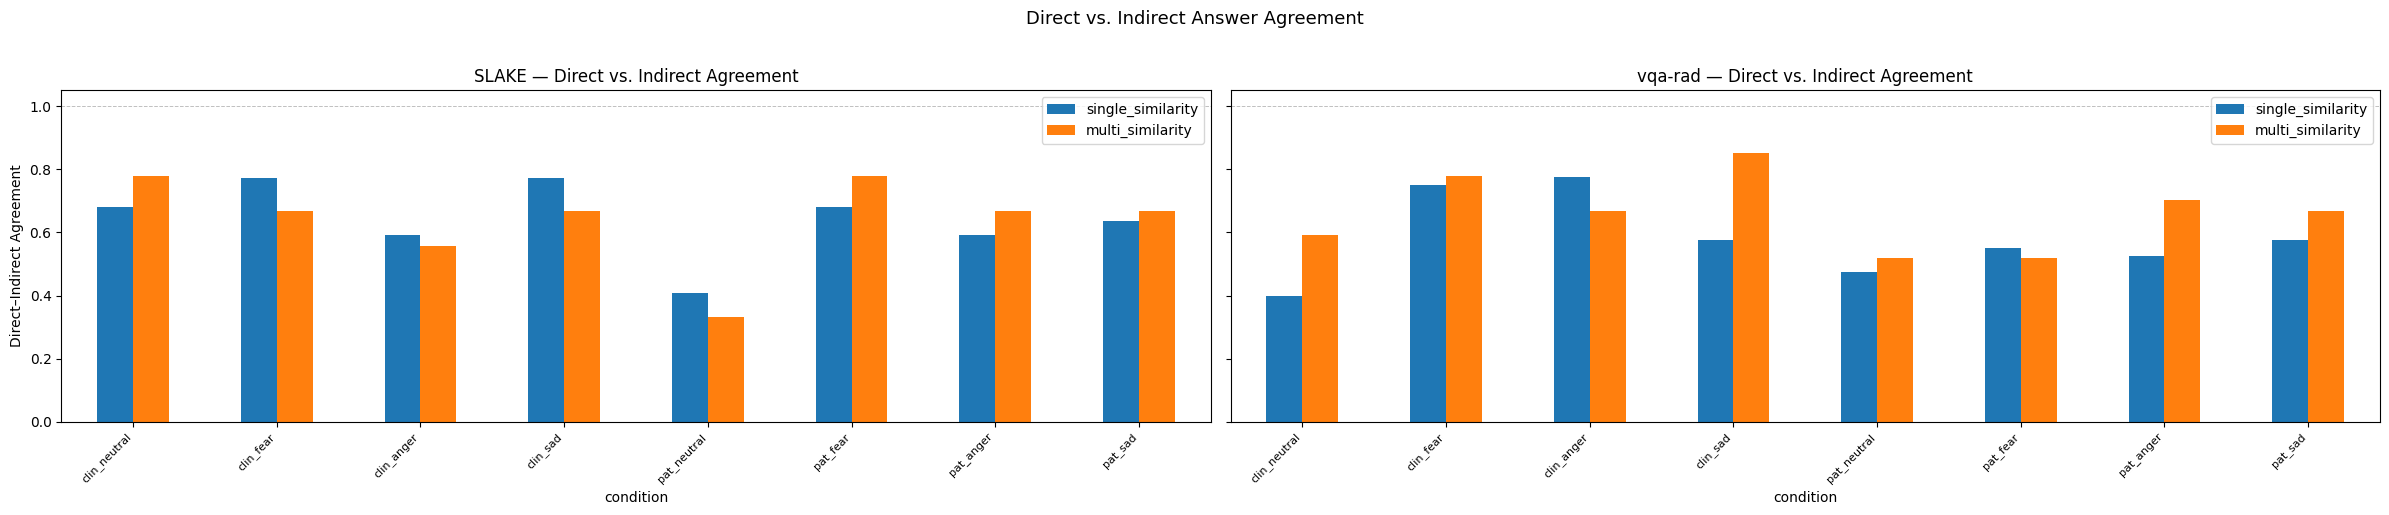

In [42]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(12 * len(DATASETS), 5), sharey=True)
if len(DATASETS) == 1:
    axes = [axes]

for ax, ds in zip(axes, DATASETS):
    if ds not in di_tables: continue
    df_plot = (
        di_tables[ds]
        .set_index("condition")[["single_similarity", "multi_similarity"]]
    )
    df_plot.plot(kind="bar", ax=ax)
    ax.set_ylabel("Direct–Indirect Agreement")
    ax.set_title(f"{ds} — Direct vs. Indirect Agreement")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)

plt.suptitle("Direct vs. Indirect Answer Agreement", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 12. Cross-Dataset Accuracy Difference

For each prompt condition, compute accuracy difference between datasets (Dataset2 − Dataset1).
Positive = Dataset2 performs better on that prompt; negative = Dataset1 performs better.
Useful for identifying which emotion/role prompts are sensitive to dataset content.

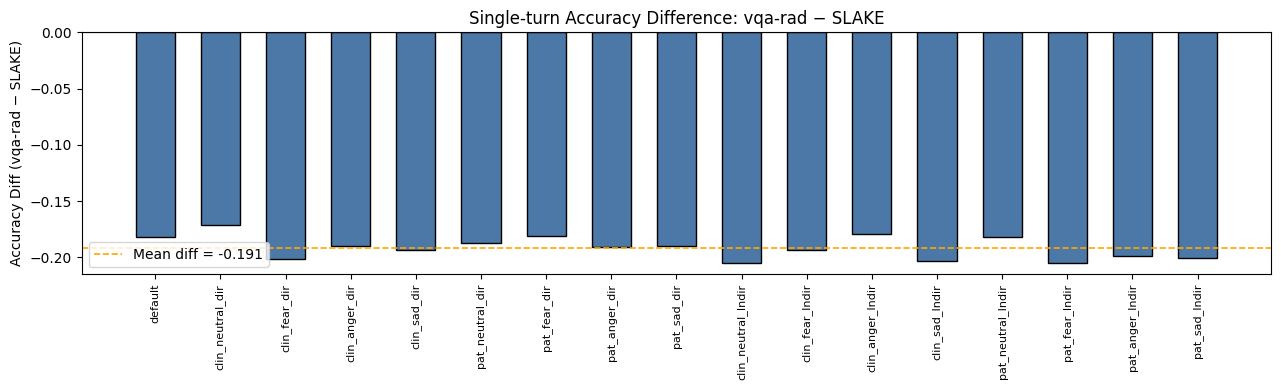

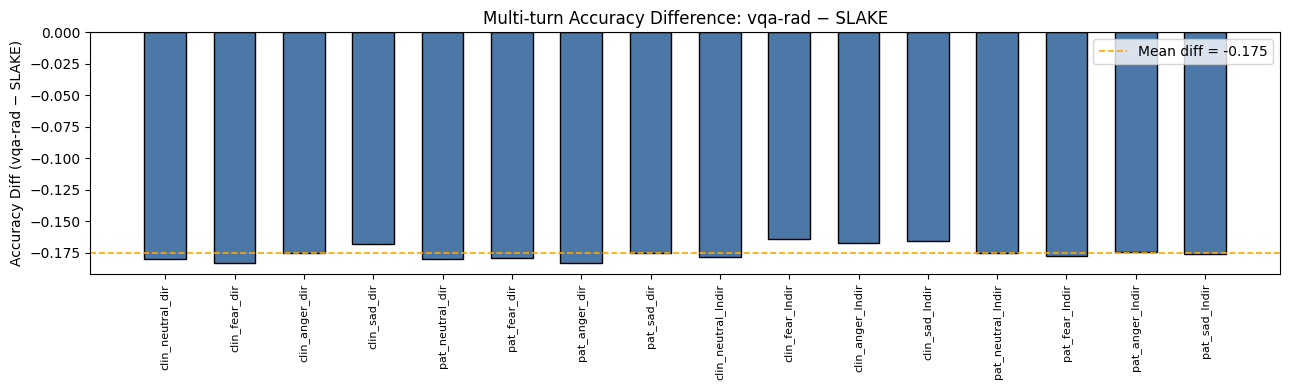

In [43]:
if len(DATASETS) == 2:
    ds1, ds2 = DATASETS

    if data[ds1] and data[ds2]:
        wt1 = data[ds1]["wide_table"].set_index("prompt")
        wt2 = data[ds2]["wide_table"].set_index("prompt")

        common_prompts = wt1.index.intersection(wt2.index)

        for mode in ("single", "multi"):
            col = f"{mode}_acc"
            if col not in wt1.columns or col not in wt2.columns:
                continue

            diff = (wt2.loc[common_prompts, col] - wt1.loc[common_prompts, col]).dropna()

            fig, ax = plt.subplots(figsize=(13, 4))
            # Color bars by which dataset is higher
            colors = [DS_COLORS.get(ds2, "#E45756") if v >= 0
                      else DS_COLORS.get(ds1, "#4C78A8") for v in diff]
            ax.bar(range(len(diff)), diff.values, color=colors, edgecolor="black", width=0.6)
            ax.set_xticks(range(len(diff)))
            ax.set_xticklabels(diff.index, rotation=90, fontsize=8)
            ax.axhline(0, color="black", linewidth=0.8)
            ax.set_ylabel(f"Accuracy Diff ({ds2} − {ds1})")
            ax.set_title(f"{mode.capitalize()}-turn Accuracy Difference: {ds2} − {ds1}")

            # Mark mean difference
            mean_diff = diff.mean()
            ax.axhline(mean_diff, color="orange", linestyle="--",
                       linewidth=1.2, label=f"Mean diff = {mean_diff:.3f}")
            ax.legend()
            plt.tight_layout()
            plt.show()
else:
    print("Cross-dataset difference plot requires exactly two datasets in DATASETS.")

## 13. Prompt Family Summary

Group all prompts into four families:
single-direct / single-indirect / multi-direct / multi-indirect.

Compute mean accuracy, yes-rate, and off-diagonal similarity per family.
Displayed as a pivot table and grouped bar chart across both datasets,
to assess whether prompt style effects are stable across datasets.

In [44]:
family_defs = {
    "single_direct":   [p for p in row_order       if p.endswith("_dir")],
    "single_indirect": [p for p in row_order       if p.endswith("_Indir")],
    "multi_direct":    [p for p in multi_row_order if p.endswith("_dir")],
    "multi_indirect":  [p for p in multi_row_order if p.endswith("_Indir")],
}

all_family_rows = []
for ds in DATASETS:
    if not data[ds]: continue
    wt  = data[ds]["wide_table"]
    ybt = data[ds]["yes_bias_table"]
    ssm = data[ds]["single_sim"]
    msm = data[ds]["multi_sim"]

    for family, prompts in family_defs.items():
        mode    = "single" if family.startswith("single") else "multi"
        acc_col = f"{mode}_acc"
        yr_col  = f"{mode}_yes_rate"
        mat     = ssm if mode == "single" else msm

        valid_prompts     = [p for p in prompts if p in wt["prompt"].values]
        valid_mat_prompts = [p for p in prompts if p in mat.index] if not mat.empty else []

        mean_acc = wt.loc[wt["prompt"].isin(valid_prompts), acc_col].mean() \
                   if acc_col in wt.columns else np.nan
        mean_yr  = ybt.loc[ybt["prompt"].isin(valid_prompts), yr_col].mean() \
                   if yr_col in ybt.columns else np.nan
        mean_sim = mean_off_diagonal(mat.loc[valid_mat_prompts, valid_mat_prompts]) \
                   if len(valid_mat_prompts) > 1 else np.nan

        all_family_rows.append({
            "dataset":         ds,
            "family":          family,
            "mean_accuracy":   round(mean_acc, 3),
            "mean_yes_rate":   round(mean_yr,  3),
            "mean_similarity": round(mean_sim, 3) if not np.isnan(mean_sim) else np.nan,
        })

family_df = pd.DataFrame(all_family_rows)
display(family_df.pivot(index="family", columns="dataset").round(3))

mean_accuracy         mean_yes_rate         mean_similarity        
dataset                 SLAKE vqa-rad         SLAKE vqa-rad           SLAKE vqa-rad
family                                                                             
multi_direct            0.971   0.793         0.488   0.430           0.869   0.884
multi_indirect          0.964   0.791         0.490   0.408           0.687   0.705
single_direct           0.973   0.784         0.488   0.410           0.899   0.790
single_indirect         0.959   0.763         0.489   0.388           0.664   0.750

### 13.1 Prompt Family Accuracy Bar Chart

Grouped bar chart of mean accuracy per prompt family across both datasets.
Shows whether direct/indirect and single/multi differences are consistent
across the two datasets.

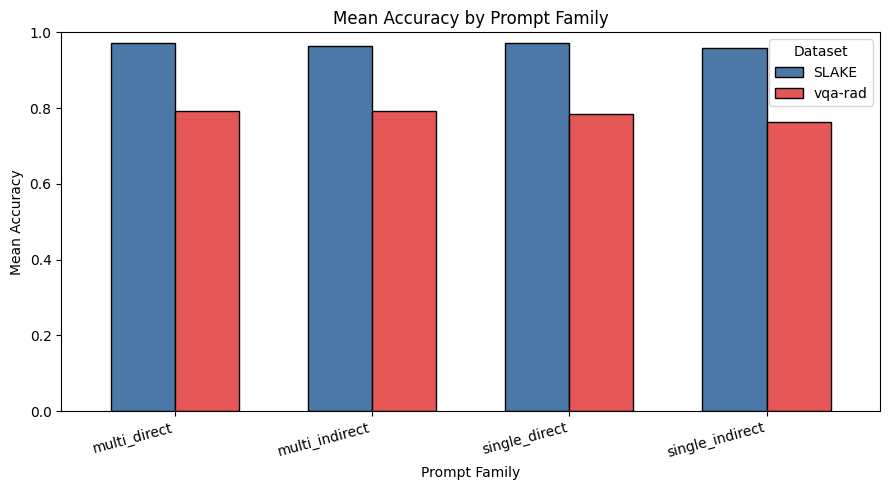

In [45]:
if not family_df.empty:
    pivot = family_df.pivot(index="family", columns="dataset", values="mean_accuracy")

    ax = pivot.plot(
        kind="bar", figsize=(9, 5),
        color=[DS_COLORS.get(ds, "#888") for ds in pivot.columns],
        edgecolor="black", width=0.65,
    )
    ax.set_xlabel("Prompt Family")
    ax.set_ylabel("Mean Accuracy")
    ax.set_title("Mean Accuracy by Prompt Family")
    ax.set_xticklabels(pivot.index, rotation=15, ha="right")
    ax.set_ylim(0, 1.0)
    ax.legend(title="Dataset")
    plt.tight_layout()
    plt.show()